# **California Housing Price Prediction**

## **Objective:**
The goal of this assignment is to practice working with real-world data using basic Pandas methods and performing linear regression using Scikit-Learn. You will predict housing prices based on various features from the California housing dataset.

* Details about this Dataset can be [found on Kaggle.](https://www.kaggle.com/datasets/camnugent/california-housing-prices)
  - Unlike the example you worked on in class, i.e., the Advertising dataset, you will not be importing the dataset as a CSV file. Instead, this homework will show you how to **download the dataset directly from Scikit-Learn.**  
* In short, the dataset contains information from the 1990 California census.
* So although it may not help you with predicting current housing prices like the [Zillow Zestimate dataset](https://www.kaggle.com/competitions/zillow-prize-1), (which is a much harder dataset to work with) it does provide an accessible introductory dataset to get your hands dirty about the basics of data analysis using Scikit-learn.
* Reference: Pace, R. Kelley, and Ronald Barry. "*Sparse spatial autoregressions.*" Statistics & Probability Letters 33.3 (1997): 291-297 ([link to paper](https://spatial-statistics.com/pace_manuscripts/spletters_ms_dir/statistics_prob_lets/html/ms_sp_lets1.html))
  - From Sec. B (titled "Data") of the paper:  *"We collected information on the variables using all the block groups in California from the 1990 Census. In this sample a block group on average includes 1425.5 individuals living in a geographically compact area. Naturally, the geographical area included varies inversely with the population density. We computed distances among the centroids of each block group as measured in latitude and longitude. We excluded all the block groups reporting zero entries for the independent and dependent variables. The final data contained 20,640 observations on 9 variables."*

### Begin with standard imports.
```python
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
```

In [65]:
import numpy as np  
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

## Task 1: Downloading the dataset and converting to a Pandas DataFrame.
### **Download directly from Scikit-Learn**
- Again, notice that this is different from the method used in class (reading a <code>.csv</code> file on your machine as a Pandas DataFrame).
- Use the **California Housing Price dataset** from Scikit-Learn.
- You can load the dataset using the information available here:
  - https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html
  - Additional information: https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html
  - Explain in your own words (a) what the `fetch_california_housing` method does, and (b) how the `as_frame=True` option can be used to produce a Pandas DataFrame (do you need to do anything extra after using the above method with the `as_frame` option?).
  - Does Scikit-Learn have any other example datasets? If yes, name two others. 

In [66]:
from sklearn.datasets import fetch_california_housing    
housing = fetch_california_housing(as_frame=True)
df = housing.frame
  

from sklearn.datasets import fetch_california_housing    # Load the California housing dataset
## a) fetch_california_housing() is a Scikit-Learn function that downloads and loads the California Housing dataset 
- so it can be used directly in Python for machine learning. Instead of reading a CSV file manually from my computer,
- this method gets the dataset for me and returns it in a ready-to-use format
## b) The option as_frame=True tells Scikit-Learn to return the dataset as Pandas objects instead of NumPy arrays. 
- When I use this option, data is returned as a Pandas DataFrame, target is returned as a Pandas Series, and frame contains the full dataset together in one Pandas DataFrame . This means I do not need to do any extra conversion with pd.DataFrame() after using as_frame=True, because the method already gives me the data in Pandas format. The Scikit-Learn course example also shows fetch_california_housing(as_frame=True) being used directly and then accessing .frame.head() as a full DataFrame

## c) Yes, Scikit-Learn has many other example datasets. 
 - examples are load_iris , and load_wine , load_diabetes , load_breast_cancer, load_digits
- 
 

# Enter your code here



### **Task 2: Initial Exploration**
1. Print the first 3 rows of the DataFrame.
2. Print and study the features of the dataframe. What does each of the 8 features represent? Which column is the regression label? You may have to search the web for this information.
3. Check for null and non-null values.
4. How many unique values do the `Latitude` and `Longitude` features have?
5. The downloaded dataset has one column missing, viz, `ocean_proximity`.
   * This data has been provided as a separate `.csv` file. Read this file into a Pandas DataFrame.
   * Append this as a new column into your original DataFrame. Make sure to use the correct value for `axis` while appending (is it `axis=0` or `axis=1`?).
   * Finally, `ocean_proximity` values need to be converted into numerical values before they can be used for regression. Given the following dictionary, what Pandas command will you use to to convert `ocean_proximity` values into numerical values?
     ```python
     keys = df['ocean_proximity'].unique()
     values = range(len(keys))
     proximity_map = {keys[i]:values[i] for i in range(len(keys))}
     ```
6. Review your notes for Seaborn's `boxplot` method. Plot `ocean_proximity` vs `MedHouseVal`. What can you infer from this plot? Do house prices follow any discernable trend with respect to `ocean_proximity`?
7. Plot a jointplot of `MedInc` vs `MedHouseVal`. What general trend can you infer from this plot?
8. Create a separate DataFrame that contains only integer and floating point values. You might want to review the literature for the `DataFrame.info()` and `DataFrame.select_dtypes()` methods.

### Freddie Karlbom's blog.
https://freddiek.github.io/2018/02/25/california-housing-data-exploration.html

In [67]:
df.head(3)   # Print the first 3 rows

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


## 2) What do the 8 features represent? Which column is the regression label?

Scikit-learn describes the 8 features as:

- MedInc = median income in the block group
- HouseAge = median house age in the block group
- AveRooms = average number of rooms per household
-  AveBedrms = average number of bedrooms per household
- Population = block group population
- AveOccup = average number of household members
- Latitude = block group latitude
- Longitude = block group longitude

- The regression target column is MedHouseVal, which is the median house value for California districts, measured in hundreds of thousands of dollars .

In [68]:
#3) Check for null and non-null values
print(df.isnull().sum())
print(df.notnull().sum())
df.info()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
MedInc         20640
HouseAge       20640
AveRooms       20640
AveBedrms      20640
Population     20640
AveOccup       20640
Latitude       20640
Longitude      20640
MedHouseVal    20640
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
# BEFORE appending the ocean_proximity column, your DataFrame should look like this:

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [3]:
# BEFORE appending the ocean_proximity column, your DataFrame should look like this:

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [4]:
# General information about the data types in each column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [69]:

#4) How many unique values do Latitude and Longitude have?
print(df["Latitude"].nunique())
print(df["Longitude"].nunique())

862
844


In [70]:
# 5) Add the missing ocean_proximity column from the separate CSV
import pandas as pd

# Read the separate CSV file into a DataFrame
ocean_df = pd.read_csv(
    r"D:\BU\CS577\3\Assignment 3\scikit_learn_california_housing_questions\scikit_learn_california_housing_questions\Ocean_Proximity.csv")


# Append ocean_proximity as a new column to the original DataFrame
# axis=1 is correct because we are adding a column
df = pd.concat([df, ocean_df[["ocean_proximity"]]], axis=1)

# Create the mapping dictionary
keys = df["ocean_proximity"].unique()
values = range(len(keys))
proximity_map = {keys[i]: values[i] for i in range(len(keys))}

# Convert ocean_proximity values to numerical values
df["proximity_numerical"] = df["ocean_proximity"].map(proximity_map)

In [71]:
df.head()



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,ocean_proximity,proximity_numerical
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,NEAR BAY,0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,NEAR BAY,0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,NEAR BAY,0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,NEAR BAY,0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,NEAR BAY,0


In [21]:
# AFTER appending the ocean proximity column and subsequently converting string values into integer values, your Data Frame should look like this:

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,ocean_proximity,proximity_numerical
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,NEAR BAY,0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,NEAR BAY,0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,NEAR BAY,0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,NEAR BAY,0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,NEAR BAY,0


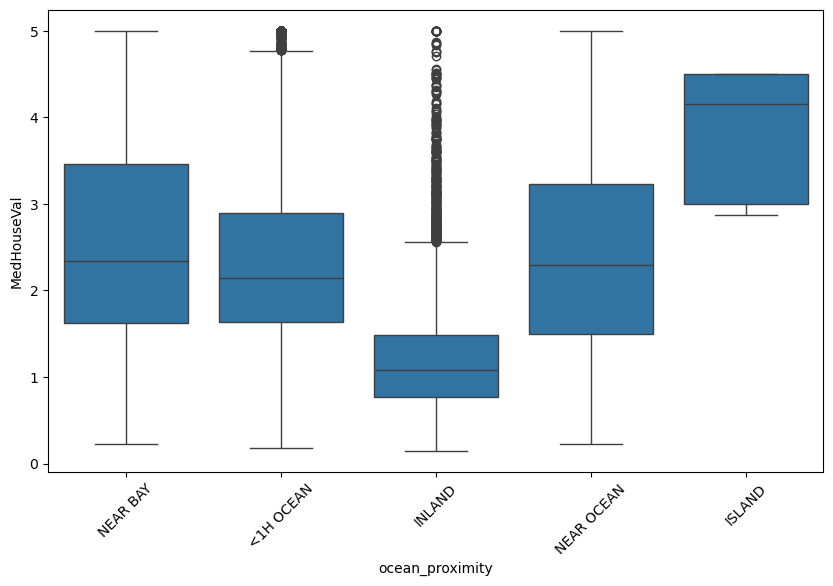

In [72]:
#6)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="ocean_proximity", y="MedHouseVal")
plt.xticks(rotation=45)
plt.show()

#Yes, the plot show a clear relationship between ocean_proximity and house prices. Houses closer to the ocean or bay generally have higher median values,
# while inland houses tend to have lower values, properties closer to water tend to be more expensive.

# INLAND has the lowest median price
# ISLAND has the highest median price
# NEAR BAY and NEAR OCEAN are relatively high
# there are many outliers, especially for INLAND


<Axes: xlabel='ocean_proximity', ylabel='MedHouseVal'>

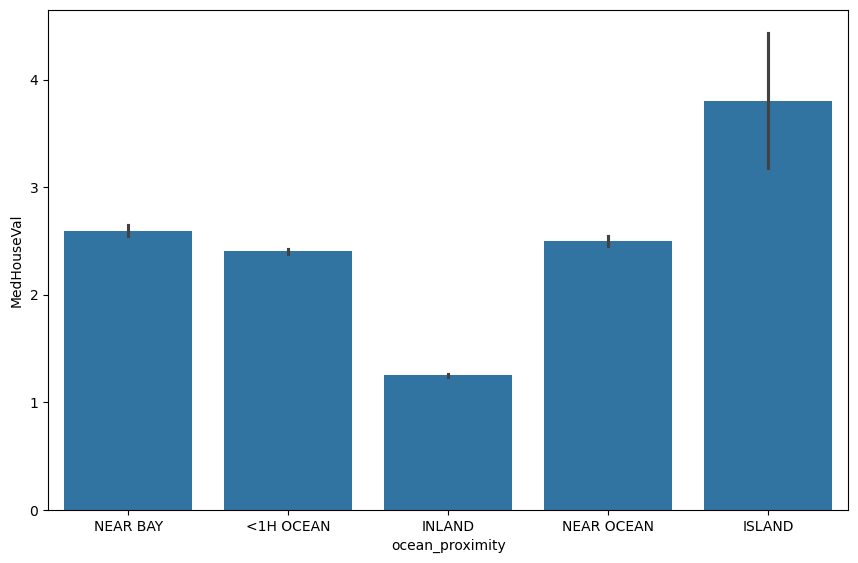

In [66]:
# The 'ocean_proximity' versus 'MedHouseVal' should look like this:

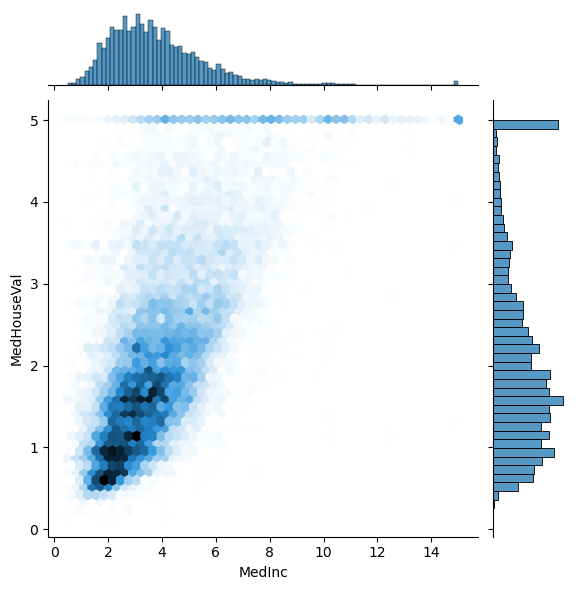

In [73]:
#7) Jointplot of MedInc vs MedHouseVal
sns.jointplot(data=df, x="MedInc", y="MedHouseVal", kind="hex")
plt.show()

# The jointplot shows a clear positive relationship between MedInc and MedHouseVal.
# IN  general, areas with higher median income tend to have higher median house values. 
# The plot also shows that many observations are concentrated in the lower-to-middle income range, and MedHouseVal appears capped near 
# Overall, MedInc seems to be a strong predictor of house valu

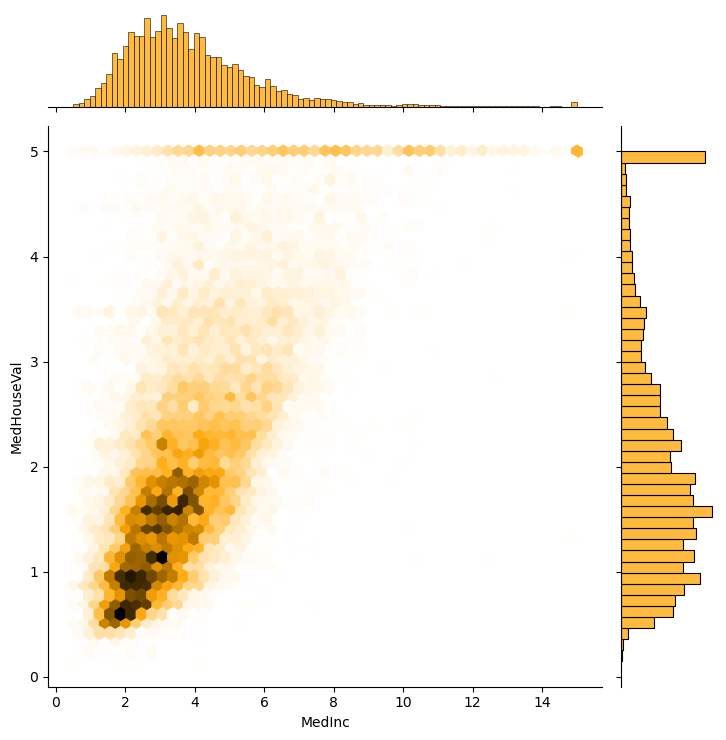

In [46]:
# The jointplot of 'MedInc' vs 'MedHouseVal' should look like this:

In [48]:
# 8) Create a separate DataFrame with only integer and floating-point values
df_numeric = df.select_dtypes(include=["number"])
df_numeric.info()
df_numeric.head()
# A separate numeric DataFrame can be created using select_dtypes(). This keeps only integer and float columns and removes non-numeric columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MedInc               20640 non-null  float64
 1   HouseAge             20640 non-null  float64
 2   AveRooms             20640 non-null  float64
 3   AveBedrms            20640 non-null  float64
 4   Population           20640 non-null  float64
 5   AveOccup             20640 non-null  float64
 6   Latitude             20640 non-null  float64
 7   Longitude            20640 non-null  float64
 8   MedHouseVal          20640 non-null  float64
 9   proximity_numerical  20640 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 1.6 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,proximity_numerical
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0


## **Task 3: Regression Analysis**
1. Split the DataFrame into a features DataFrame (`X`), and a labels Series (`y`). Be careful to include only numerical features at this stage!
2. Split the dataset into a training set and a test set. Set `random_state = 42`
3. From the `linear_model` module of Scikit-Learn, import `LinearRegression`
   * Create a linear regression object, and fit the object on the training data.
   * Generate predictions on the test data and report mean absolute error and root mean squared error for your model.
4. Create a scatter plot of test labels versus predicted labels.

Mean Absolute Error (MAE): 0.5273903462310485
Root Mean Squared Error (RMSE): 0.7283217676104775


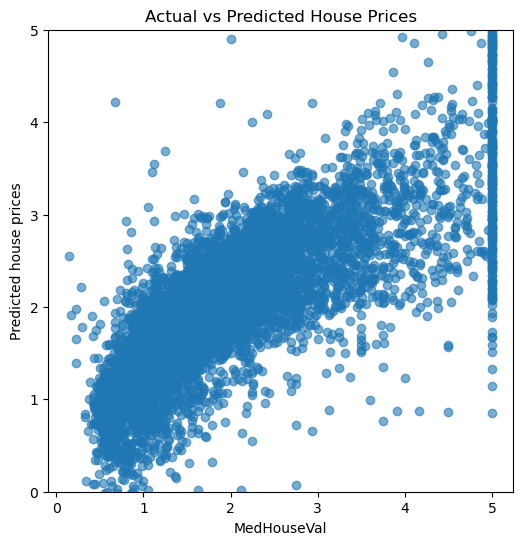

In [85]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 1) Split into features X and label y

X = df[[
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude",
    "proximity_numerical"
]]
y = df["MedHouseVal"]
# or 
# X = df.select_dtypes(include=["number"]).drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# 2) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# 3) Create and fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

# Report MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

# 4) Scatter plot of actual vs predicted labels
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("MedHouseVal")
plt.ylabel("Predicted house prices")
plt.title("Actual vs Predicted House Prices")
plt.ylim(0,5)
plt.show()

In [ ]:
" The linear regression model shows a clear positive relationship between actual and predicted house values
, which means it captures the general trend of the data. The MAE of 0.527 and RMSE of 0.728 
indicate moderate prediction error. The scatter plot also shows that predictions are more spread out
for higher house values, suggesting the model is less accurate for expensive houses. "

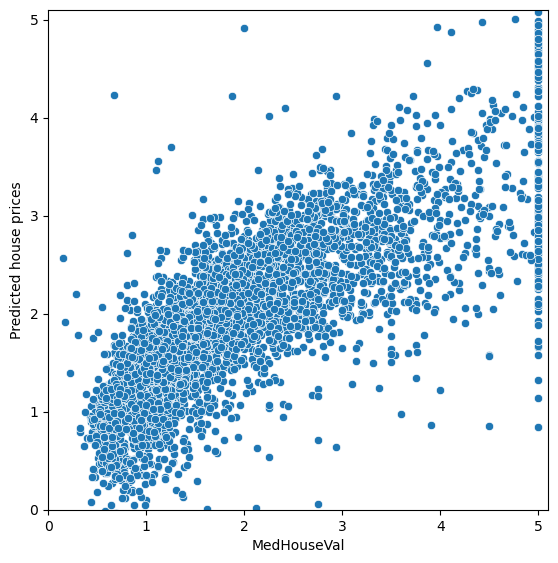

In [78]:
# The scatter plot of 'MedHouseVal' versus predicted labels should look like this: